# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [1]:
import pandas as pd
import sklearn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay


![Iris Flowers](../assets/iris_flowers.png)

### Step 1.a Load the data

In [2]:
iris = sklearn.datasets.load_iris(as_frame=True)

### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = iris.data
y = iris.target

### Step 2.b print the type of each

In [4]:
print("Type of X:", type(X))
print("Type of y:", type(y))


Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
print("\nUnique target values:", y.unique())
print("The target is categorical because it contains class labels.")
print("The task is Classification.")



Unique target values: [0 1 2]
The target is categorical because it contains class labels.
The task is Classification.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Number of samples:", X.shape[0])
print("Number of feature columns:", X.shape[1])


X shape: (150, 4)
y shape: (150,)
Number of samples: 150
Number of feature columns: 4


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
summary = X.agg(["min", "max", "median", "mean", "std"])
print("\nSummary statistics:")
print(summary)


Summary statistics:
        sepal length (cm)  sepal width (cm)  petal length (cm)  \
min              4.300000          2.000000           1.000000   
max              7.900000          4.400000           6.900000   
median           5.800000          3.000000           4.350000   
mean             5.843333          3.057333           3.758000   
std              0.828066          0.435866           1.765298   

        petal width (cm)  
min             0.100000  
max             2.500000  
median          1.300000  
mean            1.199333  
std             0.762238  


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

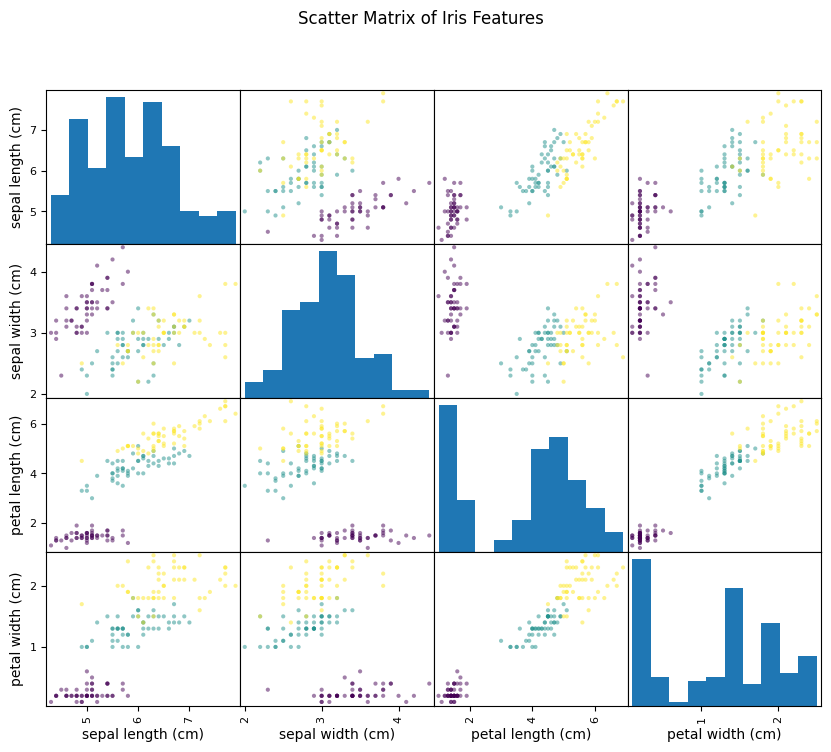

In [8]:
pd.plotting.scatter_matrix(
    X,
    c=y,
    figsize=(10, 8),
    diagonal="hist"
)
plt.suptitle("Scatter Matrix of Iris Features")
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [9]:
X_sepal = X[["sepal length (cm)", "sepal width (cm)"]]


### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [10]:
X_petal = X[["petal length (cm)", "petal width (cm)"]]


### Step 7. Initialize 2 `LogisticRegression` models

In [11]:
model_sepal = LogisticRegression(max_iter=200)
model_petal = LogisticRegression(max_iter=200)


### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [12]:
X_sepal_train, X_sepal_test, y_train_sepal, y_test_sepal = train_test_split(
    X_sepal, y, test_size=0.2, random_state=42, stratify=y
)

X_petal_train, X_petal_test, y_train_petal, y_test_petal = train_test_split(
    X_petal, y, test_size=0.2, random_state=42, stratify=y
)



### Step 9.a Train both models

In [13]:
model_sepal.fit(X_sepal_train, y_train_sepal)
model_petal.fit(X_petal_train, y_train_petal)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Step 10. Evaluate and compare both models

In [14]:
y_pred_sepal = model_sepal.predict(X_sepal_test)
y_pred_petal = model_petal.predict(X_petal_test)

acc_sepal = accuracy_score(y_test_sepal, y_pred_sepal)
acc_petal = accuracy_score(y_test_petal, y_pred_petal)

print("\nSepal model accuracy:", acc_sepal)
print("Petal model accuracy:", acc_petal)

if acc_sepal > acc_petal:
    print("Sepal features performed better.")
elif acc_petal > acc_sepal:
    print("Petal features performed better.")
else:
    print("Both models performed equally.")



Sepal model accuracy: 0.7333333333333333
Petal model accuracy: 0.9666666666666667
Petal features performed better.


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

In [15]:
print("\nPetal features usually distinguish iris flowers better and more clearly than sepal features.")



Petal features usually distinguish iris flowers better and more clearly than sepal features.


### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

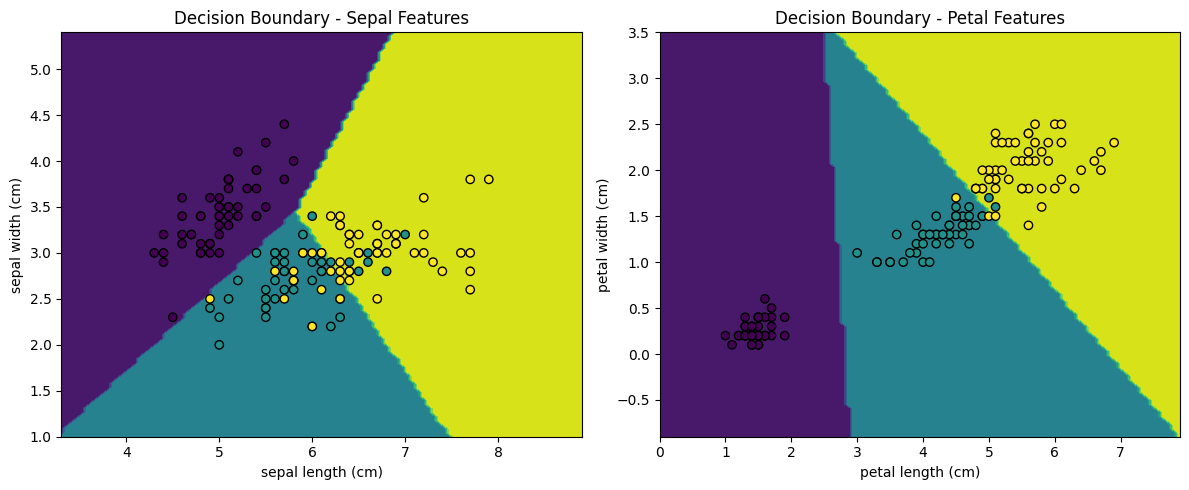

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

DecisionBoundaryDisplay.from_estimator(
    model_sepal,
    X_sepal,
    response_method="predict",
    ax=axes[0],
    xlabel="sepal length (cm)",
    ylabel="sepal width (cm)",
)
axes[0].scatter(X_sepal.iloc[:, 0], X_sepal.iloc[:, 1], c=y, edgecolor="k")
axes[0].set_title("Decision Boundary - Sepal Features")

DecisionBoundaryDisplay.from_estimator(
    model_petal,
    X_petal,
    response_method="predict",
    ax=axes[1],
    xlabel="petal length (cm)",
    ylabel="petal width (cm)",
)
axes[1].scatter(X_petal.iloc[:, 0], X_petal.iloc[:, 1], c=y, edgecolor="k")
axes[1].set_title("Decision Boundary - Petal Features")

plt.tight_layout()
plt.show()